In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import zipfile
import librosa
import torch
import numpy as np
from SMT import *
from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from tqdm import tqdm
import json
import torchaudio
from kmeans import *
from ctc import *
from smtlstm import *
from smt_accumulator import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
norm_patches = np.load("/mnt/data/SMT/norm_patches.npy")
utterance_bounds = np.load("/mnt/data/SMT/utterance_bounds.npy")
text = np.load("/mnt/data/SMT/text.npy")
mean = np.load("/mnt/data/SMT/mean.npy")
std = np.load("/mnt/data/SMT/std.npy")
zcaMatrix = np.load("/mnt/data/SMT/zcaMatrix.npy")

centroids = np.load('/mnt/data/SMT/clusters.npy')
centroids = torch.tensor(centroids).to(device)

In [3]:
smt_stats = torch.load("/mnt/data/SMT/smt_stats_2000.pt", weights_only=False)
sparse_codes = torch.load('/mnt/data/SMT/sparse_codes_2000.pt')

In [4]:
def solve_SMT_matrix(smt_stats: SMTStats):
    V = smt_stats.V
    M = smt_stats.M
    # ------------------------------------------------------------
    # Solve generalized eigenproblem M u = λ V u
    # via Cholesky reduction
    # ------------------------------------------------------------
    L = torch.linalg.cholesky(V)

    # C = L^{-1} M L^{-T}
    Linv_M = torch.linalg.solve_triangular(L, M, upper=False, left=True)
    C = torch.linalg.solve_triangular(
        L, Linv_M.transpose(-1, -2), upper=False, left=True
    ).transpose(-1, -2)

    # Symmetrize for numerical stability
    C = 0.5 * (C + C.T)

    eigvals, y = torch.linalg.eigh(C)

    # Recover generalized eigenvectors
    eigvecs = torch.linalg.solve_triangular(L.T, y, upper=True, left=True)
    return eigvals, eigvecs

In [5]:
eigvals, eigvecs = solve_SMT_matrix(smt_stats)
d=256
P = eigvecs[:, 1:d+1].T

In [6]:
beta = P.cpu()@sparse_codes.T
norm_beta, _, _, _ = preprocess_patches(beta.T.cpu().numpy()) # this switches beta to be NxD like norm_patches
norm_beta = norm_beta

normalize patches
zca patches


In [7]:
import re
from g2p_en import G2p

def make_dataloader(dataset, tokenizer, batch_size=16, shuffle=True, num_workers=0):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        collate_fn=lambda batch: ctc_collate_fn(batch, tokenizer),
    )

class NormBetaDataset(Dataset):
    """Simple utterance-level dataset built from norm_beta and utterance bounds."""
    def __init__(self, norm_beta: np.ndarray, utterance_bounds, texts=None, phonemes: bool = False):
        self.norm_beta = norm_beta
        self.utterance_bounds = list(utterance_bounds)
        self.g2p = G2p()
        self.phonemes = phonemes
        if texts is None:
            self.texts = [""] * len(self.utterance_bounds)
        else:
            if len(texts) != len(self.utterance_bounds):
                raise ValueError("texts must match utterance_bounds length")
            self.texts = list(texts)

    def __len__(self):
        return len(self.utterance_bounds)

    def __getitem__(self, idx):
        start, end = self.utterance_bounds[idx]
        x = torch.as_tensor(self.norm_beta[start:end, :], dtype=torch.float32)
        targets = self._text_to_phonemes(self.texts[idx]) if self.phonemes else self.texts[idx]
        return {
            "features": x,
            "text": targets,
        }
    
    def _text_to_phonemes(self, text, remove_stress=True):
        phonemes = self.g2p(text)

        # remove spaces/punctuation tokens
        phonemes = [p for p in phonemes if p.strip()]

        if remove_stress:
            phonemes = [p.rstrip("012") for p in phonemes]

        return phonemes

In [18]:
data_length = len(utterance_bounds)
train_split =int(data_length*0.8)
train_bounds = utterance_bounds[:train_split]
train_text = text[:train_split]
val_bounds = utterance_bounds[train_split:]
val_text = text[train_split:]
train_dataset = NormBetaDataset(norm_beta, train_bounds, train_text, phonemes=True)
val_dataset = NormBetaDataset(norm_beta, val_bounds, val_text, phonemes=True)

PHONEMES = [
'AA','AE','AH','AO','AW','AY','EH','ER','EY','IH','IY',
'OW','OY','UH','UW',
'P','B','T','D','K','G',
'CH','JH',
'F','V','TH','DH','S','Z','SH','ZH','HH',
'M','N','NG',
'L','R','W','Y'
]
tokenizer = CharTokenizer(alphabet=PHONEMES, phonemes=True)
train_loader = make_dataloader(train_dataset, tokenizer, batch_size=100, shuffle=True)
val_loader = make_dataloader(val_dataset, tokenizer, batch_size=100, shuffle=False)

# Infer input dimension from one sample
sample = train_dataset[0]["features"]
d_in = sample.shape[1]

model = SMTCTCBiLSTM(
    d_in=d_in,
    vocab_size=tokenizer.vocab_size,
    hidden_size=512,
    dropout=0.1,
    use_layernorm=True,
)



In [20]:
best_state, train_stats = train_ctc_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    tokenizer=tokenizer,
    device=device,
    num_epochs=50,
    lr=1e-3,
    weight_decay=1e-4,
    grad_clip_norm=5.0,
    decode_method="greedy"
)

if best_state is not None:
    torch.save(best_state, "best_smt_ctc_linear.pt")
    print(f"Saved best checkpoint with val CER={best_state['val_cer']:.4f}")

Epoch 001 | train_loss=18.4625 train_CER=1.6785 train_WER=0.0000 || val_loss=3.8112 val_CER=0.9983 val_WER=0.0000
Epoch 002 | train_loss=3.5709 train_CER=1.0008 train_WER=0.0000 || val_loss=3.4584 val_CER=0.9987 val_WER=0.0000
Epoch 003 | train_loss=3.4155 train_CER=0.9987 train_WER=0.0000 || val_loss=3.3817 val_CER=0.9986 val_WER=0.0000
Epoch 004 | train_loss=3.3739 train_CER=0.9986 train_WER=0.0000 || val_loss=3.3507 val_CER=0.9982 val_WER=0.0000
Epoch 005 | train_loss=3.3324 train_CER=0.9984 train_WER=0.0000 || val_loss=3.2883 val_CER=0.9972 val_WER=0.0000
Epoch 006 | train_loss=3.2074 train_CER=0.9960 train_WER=0.0000 || val_loss=3.0747 val_CER=0.9919 val_WER=0.0000
Epoch 007 | train_loss=2.9616 train_CER=0.9863 train_WER=0.0000 || val_loss=2.8215 val_CER=0.9843 val_WER=0.0000
Epoch 008 | train_loss=2.7186 train_CER=0.9813 train_WER=0.0000 || val_loss=2.6080 val_CER=0.9749 val_WER=0.0000
Epoch 009 | train_loss=2.5226 train_CER=0.9674 train_WER=0.0000 || val_loss=2.4389 val_CER=0.95

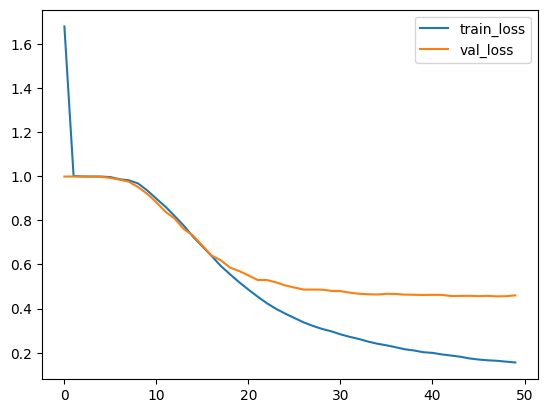

In [23]:
stats = train_stats.keys()
for key, stat in train_stats.items():
    if "CER" in key:
        plt.plot(stat)
plt.legend(stats)
plt.show()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = CharTokenizer(alphabet=PHONEMES, phonemes=True)

model = load_trained_bilstm_model(
    checkpoint_path="best_smt_ctc_linear.pt",
    d_in=d_in,
    hidden_size = 512,
    vocab_size=tokenizer.vocab_size,
    device=device,
)

for sample in val_dataset:
    pred = predict_one(
        model=model,
        features=sample["features"],
        tokenizer=tokenizer,
        device=device,
        decode_method="beam",
        beam_width=50,
        return_confidence=True,
    )

    print("Reference :", sample["text"])
    print("Predicted :", pred["text"])
    print("Confidence:", pred["confidence"])

Reference : ['F', 'AO', 'R', 'S', 'EH', 'V', 'R', 'AH', 'L', 'M', 'IH', 'N', 'AH', 'T', 'S', 'HH', 'IY', 'AH', 'T', 'ER', 'D', 'N', 'AA', 'T', 'AH', 'W', 'ER', 'D', 'B', 'AH', 'T', 'S', 'W', 'AH', 'NG', 'HH', 'IH', 'Z', 'R', 'AY', 'T', 'F', 'UH', 'T', 'W', 'IH', 'CH', 'HH', 'AH', 'NG', 'D', 'AW', 'N', 'AH', 'N', 'D', 'S', 'T', 'EH', 'R', 'D', 'AE', 'T', 'DH', 'AH', 'B', 'R', 'EY', 'Z', 'IY', 'ER', 'W', 'IH', 'DH', 'AE', 'N', 'EH', 'R', 'AH', 'V', 'S', 'AE', 'V', 'AH', 'JH', 'R', 'EH', 'V', 'ER', 'IY']
Predicted : ['F', 'ER', 'S', 'EH', 'ER', 'M', 'EH', 'N', 'EH', 'Z', 'HH', 'IY', 'AO', 'F', 'ER', 'D', 'T', 'S', 'N', 'N', 'OW', 'T', 'OW', 'ER', 'D', 'B', 'AH', 'T', 'T', 'S', 'W', 'NG', 'N', 'W', 'AA', 'Z', 'R', 'AY', 'T', 'F', 'AE', 'T', 'W', 'IH', 'HH', 'AA', 'N', 'D', 'EH', 'AW', 'AH', 'N', 'D', 'S', 'T', 'EY', 'R', 'ER', 'D', 'IH', 'DH', 'AH', 'B', 'R', 'EY', 'Y', 'ER', 'W', 'IH', 'DH', 'AH', 'N', 'T', 'EH', 'R', 'AH', 'V', 'S', 'AE', 'T', 'AH', 'JH', 'JH', 'R', 'EH', 'ER', 'EY']
Con

In [23]:
@torch.no_grad()
def inspect_ctc_posteriors(model, loader, tokenizer, device, num_batches=1):
    model.eval()

    total_blank_frac = 0.0
    total_frames = 0

    total_blank_prob = 0.0
    total_nonblank_max_prob = 0.0
    total_margin = 0.0

    batches_done = 0

    for batch in loader:
        feats = batch["features"].to(device)
        feat_lens = batch["feature_lens"]

        logits = model(feats, feat_lens)                 # (B, T, V)
        log_probs = torch.log_softmax(logits, dim=-1)
        probs = log_probs.exp()

        B, T, V = probs.shape

        for b in range(B):
            Tb = int(feat_lens[b].item())
            p = probs[b, :Tb]                            # (Tb, V)

            top2_vals, top2_ids = torch.topk(p, k=2, dim=-1)
            blank_is_top1 = (top2_ids[:, 0] == tokenizer.blank_id).float()

            total_blank_frac += blank_is_top1.sum().item()
            total_frames += Tb

            total_blank_prob += p[:, tokenizer.blank_id].sum().item()

            p_nonblank = p.clone()
            p_nonblank[:, tokenizer.blank_id] = -1.0
            max_nonblank = p_nonblank.max(dim=-1).values
            total_nonblank_max_prob += max_nonblank.sum().item()

            margin = top2_vals[:, 0] - top2_vals[:, 1]
            total_margin += margin.sum().item()

        batches_done += 1
        if batches_done >= num_batches:
            break

    print("fraction frames with blank as argmax:", total_blank_frac / total_frames)
    print("mean blank probability:", total_blank_prob / total_frames)
    print("mean max nonblank probability:", total_nonblank_max_prob / total_frames)
    print("mean top1-top2 margin:", total_margin / total_frames)

In [24]:
inspect_ctc_posteriors(model=model, 
                       loader=val_loader, 
                       tokenizer=tokenizer, 
                       device=device, 
                       num_batches=1)

fraction frames with blank as argmax: 0.7006224781524362
mean blank probability: 0.6912585832614427
mean max nonblank probability: 0.2827093431110831
mean top1-top2 margin: 0.8604909122254877
